<h1 align="center">Física Computacional</h1>
<h1 align="center">Semestre 2025-4</h1>

<h2>Sergio A. Alcalá Corona</h2>
<h2>Rodrigo Vega Vilchis</h2>

---
### Alumno: Juan Alexis Hernández Hernández
---

<h1 align="center">Práctica 5. Metodos de solución numérica para Ecuaciones Diferenciales Ordinarias</h1>

In [ ]:
import math as mt
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import scipy as sp

### 1. Metodos numéricos para ecuaciones no lineales (pendiente)

### **1. Constante de desplazamiento de Wien**: La ley de radiación de Planck nos dice que la intensidad de la radiación por unidad de área y unidad de longitud de onda $\lambda$ de un cuerpo negro a la temperatura $T$ es:

$$I(\lambda) = \frac{2\pi hc^2\lambda^{-5}}{e^{hc/\lambda k_B T} - 1}$$

### donde $h$ es la constante de Planck, $c$ es la velocidad de la luz y $k_B$ es la constante de Boltzmann.

#### **(a)** Demuestra diferenciando que la longitud de onda $\lambda$ a la que la radiación emitida alcanza su mayor intensidad, es la solución de la ecuación:

$$5e^{-hc/\lambda k_B T} + \frac{hc}{\lambda k_B T} - 5 = 0$$

#### Sustituye $x = \frac{hc}{\lambda k_B T}$ y demuestra que la longitud de onda de la radiación máxima obedece al *desplazamiento de Wien*:

$$\lambda = \frac{b}{T}$$

#### donde la *constante de desplazamiento de Wien* es $b = \frac{hc}{k_B x}$, y $x$ es la solución de la ecuación no lineal:

$$5e^{-x} + x - 5 = 0$$

#### **(b)** Escribe un programa para resolver esta ecuación con una precisión ($\varepsilon$xactitud) de $10^{-6}$ usando el método de búsqueda binaria y así, encuentra un valor para la constante de desplazamiento.


In [ ]:
# Definimos la ecuación a resolver
def f(x):
    return 5*np.exp(-x) + x - 5

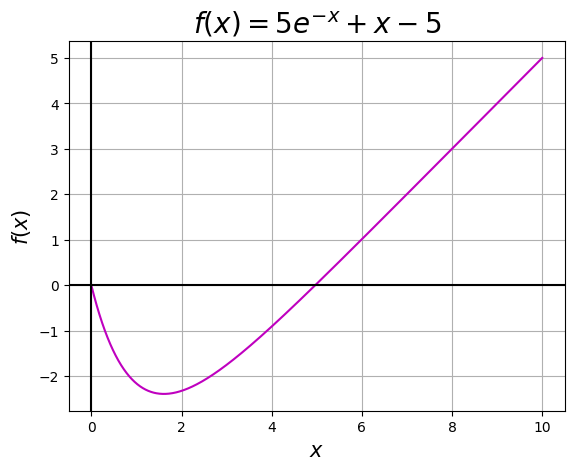

In [ ]:
# Graficamos para tener una mejor visualización del problema
X = np.linspace(0,10,1000)
Y = f(X)

pl.plot(X,Y,c='m')
pl.title(r'$f(x) = 5e^{-x} + x -5$',size=20)
pl.xlabel(r'$x$',size=15)
pl.ylabel(r'$f(x)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()

In [ ]:
# Hacemos el programa de búsqueda binaria
def busqbin(x1,x2,f,error):
  e = abs(x1-x2)
  while e > error:
    s1 = np.sign(f(x1))
    s2 = np.sign(f(x2))
    if s1 == s2:
      print("Intenta con otros puntos.")
      break
    else:
      x = 0.5*(x1 + x2)
      s = np.sign(f(x))
      if s == s1:
        x1 = x
      else:
        x2 = x
      e = abs(x1-x2)
  return x,e

In [ ]:
# Y resolvemos la ecuación
x,e = busqbin(4,6,f,1e-6)
print('La solución de la ecuación es:',x,'con un error de:',e)

La solución de la ecuación es: 4.965113639831543 con un error de: 9.5367431640625e-07


Por lo tanto, la *constante de Wien* es:

In [ ]:
h = 6.62607015e-34 # J*s
c = 299792458 # m/s (en el vacío)
k = 1.380649e-23 # J/K

b = (h*c)/k * (1/x)
b

0.0028977723006411364

#### **(c)** La ley de desplazamiento es la base del método de *pirometría óptica*, un método para medir las temperaturas de los objetos observando el color de la radiación térmica que emiten. El método se utiliza habitualmente para estimar las temperaturas superficiales de cuerpos astronómicos, como el Sol. El pico de longitud de onda en la radiación emitida por el Sol cae en $\lambda = 502\ \text{nm}$. A partir de las ecuaciones anteriores y el valor de la constante de desplazamiento, estima la temperatura de la superficie del Sol.

Tenemos que $\lambda = \frac{b}{T}$, entonces

In [ ]:
L = 502e-9

T = b/L
print('La temperatura del Sol es de',T,'Kelvin.')

La temperatura del Sol es de 5772.454782153658 Kelvin.


### **2. El punto de Lagrange**: Hay un punto mágico entre la Tierra y la Luna, llamado punto de Lagrange $L_1$, en el cual un satélite orbitará la Tierra en perfecta sincronía con la Luna, permaneciendo siempre entre las dos. Esto funciona porque la atracción de la Tierra hacia adentro y la atracción de la Luna hacia afuera se combinan para crear exactamente la fuerza centrípeta necesaria para mantener al satélite en esa órbita. Esta es la configuración:


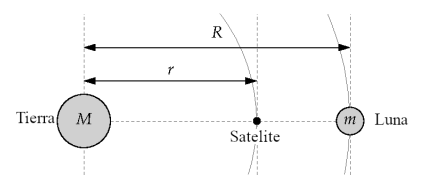

#### **(a)** Suponiendo que las órbitas son circulares y que la Tierra es mucho más masiva que la Luna o el satélite, demuestra que la distancia $r$ desde el centro de la Tierra hasta el punto $L_1$ satisface:

$$\frac{GM}{r^2} - \frac{Gm}{(R - r)^2} = \omega^2 r$$

#### donde $M$ y $m$ son las masas de la Tierra y la Luna, $G$ es la constante gravitacional de Newton y $\omega$ es la velocidad angular tanto de la Luna como del satélite.

#### **(b)** La ecuación anterior es una ecuación polinómica de quinto orden en $r$. Estas ecuaciones no se pueden resolver exactamente de forma cerrada, pero es sencillo resolverlas numéricamente. Escribe un programa que utilice el **método de Newton** para resolver la distancia $r$ desde la Tierra hasta el punto $L_1$. Calcula una solución con una precisión ($\varepsilon$xactitud) de al menos cuatro cifras significativas.

#### Los valores de los distintos parámetros son:
$$\begin{align*}
G &= 6.674 \times 10^{-11}~\text{m}^3~\text{kg}^{-1}~\text{s}^{-2}\\
M &= 5.974 \times 10^{24}~\text{kg}\\
m &= 7.348 \times 10^{22}~\text{kg}\\
R &= 3.844 \times 10^{8}~\text{m}\\
\omega &= 2.662 \times 10^{-6}~\text{s}^{-1}
\end{align*}$$

#### Considera que deberás elegir un valor inicial adecuado para $r$.

In [ ]:
# Definimos la ecuación a resolver y su derivada
def f(x):
  G = 6.674e-11
  M = 5.974e24
  m = 7.348e22
  R = 3.844e8
  w = 2.662e-6
  return (G*M)/(x**2) - (G*m)/((R-x)**2) - (w**2)*x

def df(x):
  G = 6.674e-11
  M = 5.974e24
  m = 7.348e22
  R = 3.844e8
  w = 2.662e-6
  return (-2*G*M)/(x**3) - (2*G*m)/((R-x)**3) - w**2

/tmp/ipython-input-479847108.py:8: RuntimeWarning: divide by zero encountered in divide
  return (G*M)/(x**2) - (G*m)/((R-x)**2) - (w**2)*x


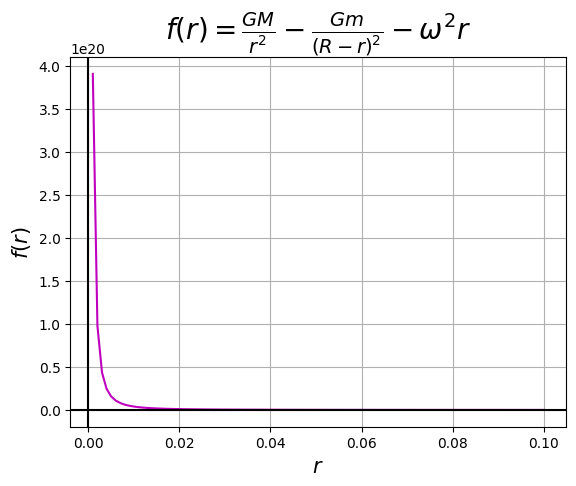

In [ ]:
# Graficamos para tener una mejor visualización del problema
X = np.linspace(0,0.1,100)
Y = f(X)

pl.plot(X,Y,c='m')
pl.title(r'$f(r) = \frac{GM}{r^2}-\frac{Gm}{(R-r)^2}-\omega^2r$',size=20)
pl.xlabel(r'$r$',size=15)
pl.ylabel(r'$f(r)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()

In [ ]:
# Hacemos el programa del método de Newton
def newrap(x0,f,df,error):
  x = x0 - f(x0)/df(x0)
  e = abs(x-x0)
  while e > error:
    x0 = x
    x = x0 - f(x0)/df(x0)
    e = abs(x-x0)
  return x,e

In [ ]:
r,e = newrap(0.01,f,df,1e-4)
print('El punto de Lagrange está a',r,'m del centro de la Tierra; calculado con un error de',e)

El punto de Lagrange está a 326045071.66535544 m del centro de la Tierra; calculado con un error de 0.0


### 2. Métodos numéricos para ecuaciones Diferenciales Ordinarias

### **1. Un filtro pasa bajos**: El siguiente es un circuito electrónico simple con una resistencia y un capacitor:

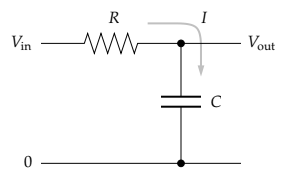

### Este circuito actúa como un filtro pasa bajos: envías una señal por la izquierda y sale filtrada por la derecha.

### Usando la *ley de Ohm*, la *ley del capacitor* y suponiendo que la carga de salida tiene una impedancia muy alta, de modo que una cantidad insignificante de corriente fluye a través de ella, es posible escribir las ecuaciones que gobiernan el circuito de la siguiente manera. Sea $I$ la corriente que fluye a través de $R$ y dentro del capacitor, y sea $Q$ la carga en el capacitor. Entonces:

$$IR = V_{in} - V_{out}, \quad Q = C V_{out}, \quad I = \frac{dQ}{dt}$$

### Sustituyendo la segunda ecuación en la tercera y luego el resultado en la primera ecucación, encontramos que $V_{in} - V_{out} = RC \frac{dV_{out}}{dt}$, o equivalentemente:

$$\frac{dV_{out}}{dt} = \frac{1}{RC} (V_{in} - V_{out})$$

#### **(a)** Escribe un programa (o modifica algunos de los vistos en clase) para resolver esta ecuación para $V_{out}(t)$ usando:

#### 1) el método de Euler, y
#### 2) el método de Runge-Kutta de cuarto orden,  

#### cuando la señal de entrada es una onda cuadrada con frecuencia $1$ y amplitud $1$:

$$
V_{in}(t) = \begin{cases}
1 & \text{si } \lfloor 2t \rfloor \text{ es par} \\
-1 & \text{si } \lfloor 2t \rfloor \text{ es impar}
\end{cases}
$$

#### donde $\lfloor x \rfloor$ significa $x$ redondeado hacia abajo al siguiente entero mas bajo. Utiliza el programa para graficar la salida del circuito del filtro desde $t = 0$ hasta $t = 10$, cuando $RC = 0.01$, $0.1$ y $1$, con la condición inicial $V_{out}(0) = 0$.  
#### Tendrás que decidir qué valor de $h$ usar para tu cálculo. Los valores pequeños dan resultados más precisos, pero el programa tardará más en ejecutarse.


Método de Euler:

In [ ]:
# Definimos la ecuación diferencial a resolver
def dVout(Vout,t,RC):
  criterio = int(2*t)
  if criterio%2 == 0:
    Vin = 1
  else:
    Vin = -1
  return 1/(RC) * (Vin-Vout)

In [ ]:
# Hacemos el programa del método de Euler

# dx: ecuación diferencial a resolver (dx(t)/dt)
# x0: condicion inicial (x(t_0))
# t0: intervalo inicial
# t1: intervalo final
# h: intervalo de pasos (dt)
def Euler(dx,x0,t0,t1,h,RC): # En este problema en particular consideramos el valor RC
  X = [x0]
  T = [t0]
  while t0 < t1:
    x = x0 + dx(x0,t0,RC)*h
    t = t0 + h
    X.append(x)
    T.append(t)
    x0 = x
    t0 = t
  return T,X

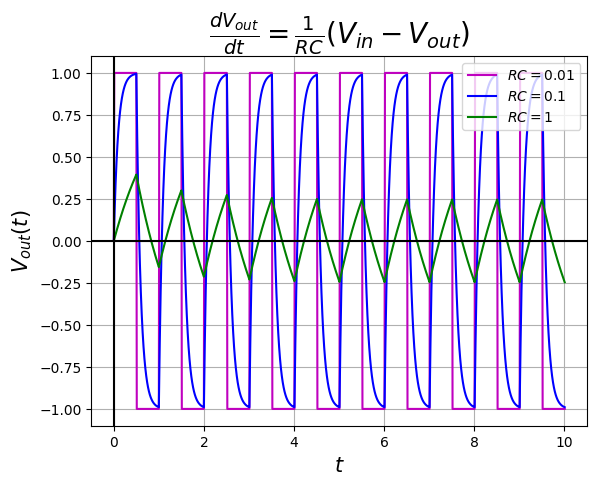

In [ ]:
h = 0.01
x1,y1 = Euler(dVout,0,0,10,h,0.01)
x2,y2 = Euler(dVout,0,0,10,h,0.1)
x3,y3 = Euler(dVout,0,0,10,h,1)

pl.plot(x1,y1,c='m',label=r'$RC=0.01$')
pl.plot(x2,y2,c='b',label=r'$RC=0.1$')
pl.plot(x3,y3,c='g',label=r'$RC=1$')
pl.title(r'$\frac{dV_{out}}{dt} = \frac{1}{RC}(V_{in}-V_{out})$',size=20)
pl.xlabel(r'$t$',size=15)
pl.ylabel(r'$V_{out}(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()
pl.legend()

Método Runge-Kutta:

In [ ]:
# dx: ecuación diferencial a resolver (dx(t)/dt)
# x0: condicion inicial (x(t_0))
# t0: intervalo inicial
# t1: intervalo final
# h: intervalo de pasos (dt)
def RungeKutta(dx,x0,t0,t1,h,RC): # Igual, de manera particular, consideramos RC
  X = [x0]
  T = [t0]
  while t0 < t1:
    k1 = dx(x0,t0,RC)*h
    k2 = dx(x0+0.5*k1,t0+0.5*h,RC)*h # Usamos la versión donde también incrementa a t
    k3 = dx(x0+0.5*k2,t0+0.5*h,RC)*h # ya que nuestra ecuación a resolver también
    k4 = dx(x0+k3,t0+h,RC)*h # depende de ella

    x = x0 + (k1 + 2*k2 + 2*k3 + k4)/6
    t = t0 + h
    X.append(x)
    T.append(t)
    x0 = x
    t0 = t
  return T,X

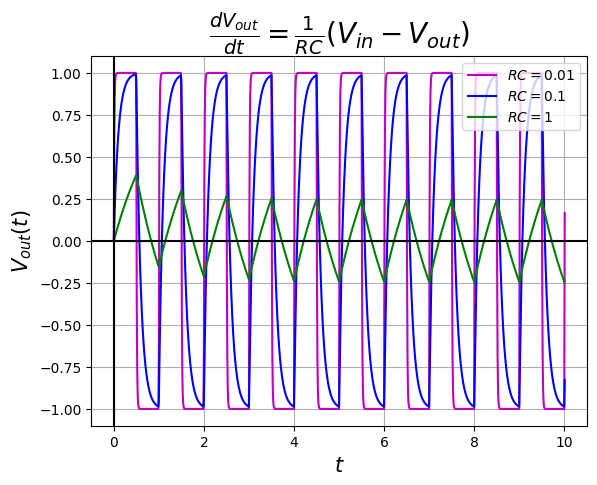

In [ ]:
h = 0.01
x1,y1 = RungeKutta(dVout,0,0,10,h,0.01)
x2,y2 = RungeKutta(dVout,0,0,10,h,0.1)
x3,y3 = RungeKutta(dVout,0,0,10,h,1)

pl.plot(x1,y1,c='m',label=r'$RC=0.01$')
pl.plot(x2,y2,c='b',label=r'$RC=0.1$')
pl.plot(x3,y3,c='g',label=r'$RC=1$')
pl.title(r'$\frac{dV_{out}}{dt} = \frac{1}{RC}(V_{in}-V_{out})$',size=20)
pl.xlabel(r'$t$',size=15)
pl.ylabel(r'$V_{out}(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()
pl.legend()

#### **(b)** Con base en las gráficas producidas por tu programa, describe lo que ves y explica qué está haciendo el circuito.

Parece ser un regulador del voltaje de salida, y lo hace de forma periódica. Podría decir que tener un $RC$ de $0.01$ es el que mejor funciona ya que respeta la forma de onda cuadrada del voltaje de entrada.

Si tomamos un $RC$ de $0.1$ se comporta de forma suave las variaciones de voltaje de salida, pero en el ùltimo caso nos da totalmente picos de voltaje (aunque la magnitud es pequeña).

#### **(c)** Describe brevemente cómo se compara (es decir, cuáles son las mayores diferencias, si es que las hay), resolver el sistema con el método de Euler y el de Runge-Kutta.

No hay gran diferencia; el de Runge-Kutta solo parece alcanzar más puntos a valores muy cercanos al $10$ (final de la gráfica), que no afecta en nada al de Euler ya que la solución es periódica (ese patrón se repetiría en el de Euler si tomamos un intervalo un poco más grande).

### **2. El modelo de Lotka-Volterra (** ***predador-presa*** **)**: Como vimos en clase, un caso particular del *modelo de Lotka-Volterra* son las ecuaciones de interacción *depredador-presa* entre dos especies biológicas. Sean las variables $x$ e $y$ proporcionales al tamaño de las poblaciones de dos especies, tradicionalmente llamadas “conejos” (la presa) y “zorros” (los depredadores).
### Se puede pensar que $x$ y $y$ son la población en miles, digamos, de modo que $x = 2$ significa que hay $2000$ conejos. Estrictamente, los únicos valores permitidos de $x$ y $y$ serían múltiplos de $0.001$, ya que sólo se puede tener números enteros de conejos o zorros. Pero $0.001$ es un espacio de valores bastante cercano, por lo que es una aproximación decente tratar $x$ e $y$ como números reales continuos siempre que ninguno se acerque mucho a cero.

### Así, en el modelo de Lotka-Volterra (*predador-presa*), los conejos se reproducen a un ritmo proporcional a su población, pero los zorros se los comen a un ritmo proporcional tanto a su propia población como a la población de zorros, es decir:

$$\frac{dx}{dt} = \alpha x - \beta x y$$

### donde $\alpha$ y $\beta$ son constantes. Al mismo tiempo, los zorros se reproducen a un ritmo proporcional al ritmo al que comen conejos, porque necesitan alimento para crecer y reproducirse, pero también mueren de viejos a un ritmo proporcional a su propia población:

$$\frac{dy}{dt} = \gamma x y - \delta y$$

### donde $\gamma$ y $\delta$ también son constantes.

#### **(a)** Escribe un programa para resolver estas ecuaciones usando  

#### 1) el método de Euler y  
#### 2) el método de Runge-Kutta de cuarto orden  

#### para el caso $\alpha = 1$, $\beta = \gamma = 0.5$ y $\delta = 2$, comenzando desde la condición inicial $x = y = 2$.

Ahora es un problema de 2 dimensiones así que vamos a generalizar nuestro método de Euler anterior (que era de 1 dimensión) a este problema vectorial.

Pensemos a nuestro problema de la siguiente forma:
$$r(t) = (x(t),y(t))$$
$$\Rightarrow \frac{dr}{dt} = (\alpha x - \beta x y, \gamma x y - \delta y)$$

In [ ]:
def df(r):  # r es nuestro vector en 2D (x,y)
    alpha = 1
    beta = 0.5
    gamma = 0.5
    delta = 2

    z = np.zeros(2)
    z[0] = alpha*r[0] - beta*r[0]*r[1]
    z[1] = gamma*r[0]*r[1] - delta*r[1]

    return z

In [ ]:
# Hacemos el programa del método de Euler en 2D

# dx: ecuación diferencial a resolver
# r0: condicion inicial (x0,y0)
# t0: intervalo inicial
# t1: intervalo final
# h: intervalo de pasos (dt)
def Euler2D(dx,r0,t0,t1,h): # En este problema en particular consideramos el valor RC
  T = [t0]
  X = [r0[0]]
  Y = [r0[1]]
  while t0 < t1:
    r = r0 + dx(r0)*h
    t = t0 + h
    T.append(t)
    X.append(r[0])
    Y.append(r[1])
    r0 = r
    t0 = t
  return T,X,Y

Hacemos lo mismo con el método de Runge-Kutta:

In [ ]:
def RungeKutta2D(dx,r0,t0,t1,h):
  T = [t0]
  X = [r0[0]]
  Y = [r0[1]]
  while t0 < t1:
    k1 = dx(r0)*h
    k2 = dx(r0+0.5*k1)*h # A diferencia del ejercicio anterior, la ecuación que
    k3 = dx(r0+0.5*k2)*h # queremos resolve no depende de t, así que en este caso
    k4 = dx(r0+k3)*h # omitimos el incremento en esa variable

    r = r0 + (k1 + 2*k2 + 2*k3 + k4)/6
    t = t0 + h
    T.append(t)
    X.append(r[0])
    Y.append(r[1])
    r0 = r
    t0 = t
  return T,X,Y

#### **(b)** Haz que el programa realice gráficas que muestren

#### 1) el espacio fase del sistema ((i.e. $x$ vs $y$) y también  
#### 2) en un gráfico diferente $x$ e $y$ como función del tiempo en los mismos ejes desde $t = 0$ hasta $t = 30$.

Euler:

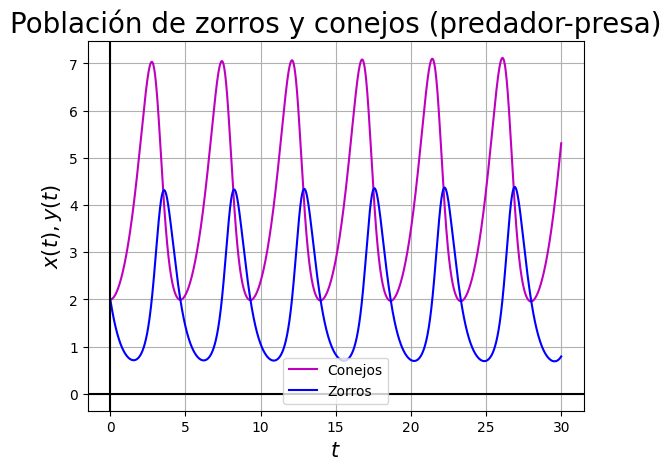

In [ ]:
x,y1,y2 = Euler2D(df,[2,2],0,30,0.001)

pl.plot(x,y1,c='m',label='Conejos')
pl.plot(x,y2,c='b',label='Zorros')
pl.title(r'Población de zorros y conejos (predador-presa)',size=20)
pl.xlabel(r'$t$',size=15)
pl.ylabel(r'$x(t),y(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()
pl.legend()

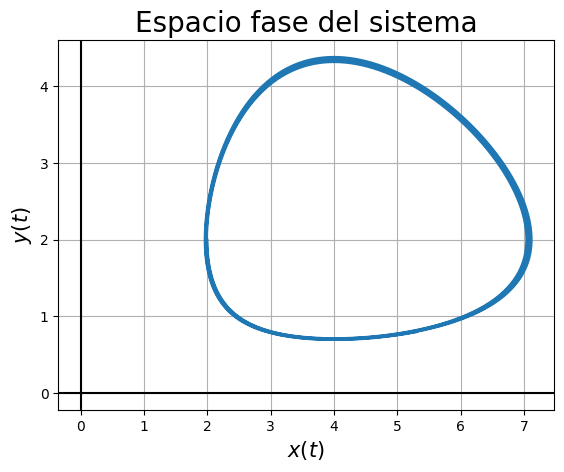

In [ ]:
pl.plot(y1,y2)
pl.title(r'Espacio fase del sistema',size=20)
pl.xlabel(r'$x(t)$',size=15)
pl.ylabel(r'$y(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()

Runge-Kutta:

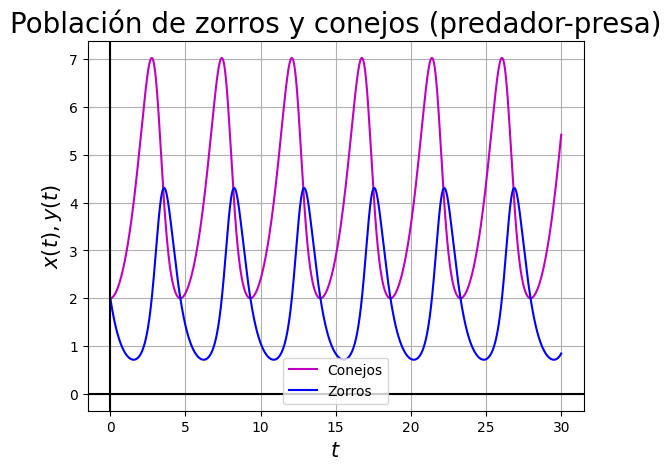

In [ ]:
x,y1,y2 = RungeKutta2D(df,[2,2],0,30,0.001)

pl.plot(x,y1,c='m',label='Conejos')
pl.plot(x,y2,c='b',label='Zorros')
pl.title(r'Población de zorros y conejos (predador-presa)',size=20)
pl.xlabel(r'$t$',size=15)
pl.ylabel(r'$x(t),y(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()
pl.legend()

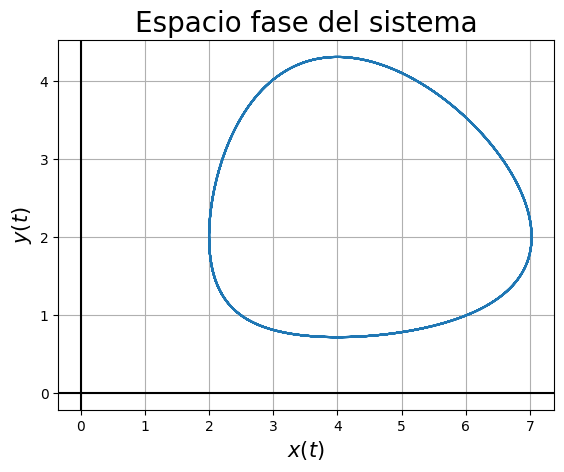

In [ ]:
pl.plot(y1,y2)
pl.title(r'Espacio fase del sistema',size=20)
pl.xlabel(r'$x(t)$',size=15)
pl.ylabel(r'$y(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()

#### **(c)** Describe con tus propias palabras lo que está sucediendo en el sistema, en términos de presas y depredadores.

Con la gráfica del espacio fase nos damos cuenta de que es un comportamiento periódico (pues cierra el "círculo"), y sí corresponde pues la condición inicial es parte de la gráfica. En otras palabras, la situación predador-presa está en "equilibrio", si una población disminuye la otra también, y si incrementan, igual, pero esto lo hacen naturalmente periódicamente, así que su existencia mutua (fuera de agentes externos) está asegurada por siempre.

#### **(d)** Describe brevemente cómo se compara resolver el sistema con el método de Euler y el de Runge-Kutta.

### **5. Las ecuaciones de Lorenz**: Uno de los conjuntos de ecuaciones diferenciales más famosos en el estudio de los *sistemas dinámicos* y los *sistemas complejos* son las *ecuaciones de Lorenz*:

$$
\frac{dx}{dt} = \sigma(y - x), \quad
\frac{dy}{dt} = rx - y - xz, \quad
\frac{dz}{dt} = xy - bz
$$

### donde $\sigma$, $r$ y $b$ son constantes. (Los nombres $\sigma$, $r$ y $b$ son extraños, pero tradicionales; siempre se usan en estas ecuaciones por razones históricas).
### Estas ecuaciones fueron estudiadas por primera vez por Edward Lorenz en 1963, quien las derivó de un modelo simplificado de patrones climáticos. La razón de su fama es que fueron uno de los primeros ejemplos incontrovertibles de *caos determinista*, la ocurrencia de movimiento aparentemente aleatorio aunque no haya aleatoriedad incorporada en las ecuaciones. Otro ejemplo de caos es el *mapeo logístico* que vimos anteriormente en el curso.

#### **(a)** Escribe un programa para resolver las ecuaciones de Lorenz para el caso $\sigma = 10$, $r = 28$ y $b = \frac{8}{3}$ en el rango de $t \in (0, 50)$ con condición inicial $(x, y, z) = (0, 1, 0)$ (puedes ampliar tus programas anteriores de los métodos Euler y/o Runge-Kutta).


Vamos a usar el método de Runge-Kutta de cuarto orden ya que brinda mejor resolución, y al igual que el ejercicio anterior, vamos a generalizarlo para dimensión 3.

In [ ]:
def RungeKutta3D(dx,r0,t0,t1,h):
  T = [t0]
  X = [r0[0]]
  Y = [r0[1]]
  Z = [r0[2]]
  while t0 < t1:
    k1 = dx(r0)*h
    k2 = dx(r0+0.5*k1)*h
    k3 = dx(r0+0.5*k2)*h
    k4 = dx(r0+k3)*h

    r = r0 + (k1 + 2*k2 + 2*k3 + k4)/6
    t = t0 + h
    T.append(t)
    X.append(r[0])
    Y.append(r[1])
    Z.append(r[2])
    r0 = r
    t0 = t
  return T,X,Y,Z

In [ ]:
# Escribimos la ecuación diferencial a resolver
def dlorenz(r):
  sigma = 10
  R = 28
  b = 8/3

  w = np.zeros(3)
  w[0] = sigma*(r[1]-r[0])
  w[1] = R*r[0] - r[1] - r[0]*r[2]
  w[2] = r[0]*r[1] - b*r[2]

  return w

In [ ]:
x,y0,y1,y2 = RungeKutta3D(dlorenz,[0,1,0],0,50,0.01)

#### **(b)** Haz que tu programa muestre una gráfica de $y$ en función del tiempo. Ten en cuenta la naturaleza impredecible del movimiento.

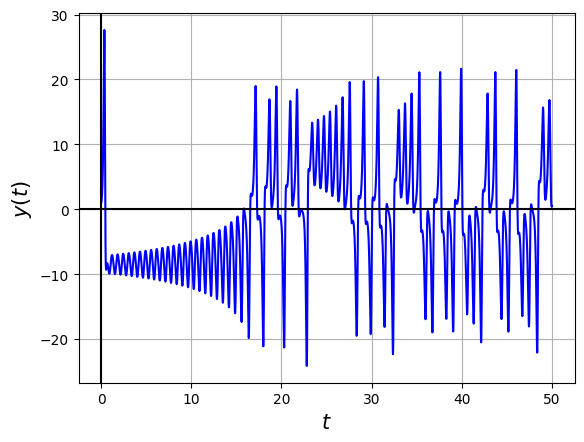

In [ ]:
pl.plot(x,y1,c='b')
pl.xlabel(r'$t$',size=15)
pl.ylabel(r'$y(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()

#### **(c)** Haz que tu programa también muestre una gráfica de $z$ contra $x$. Deberías de ver una imagen del famoso “*atractor extraño*” de las ecuaciones de Lorenz (que también vimos en clase), un diagrama desequilibrado en forma de mariposa que nunca se repite.

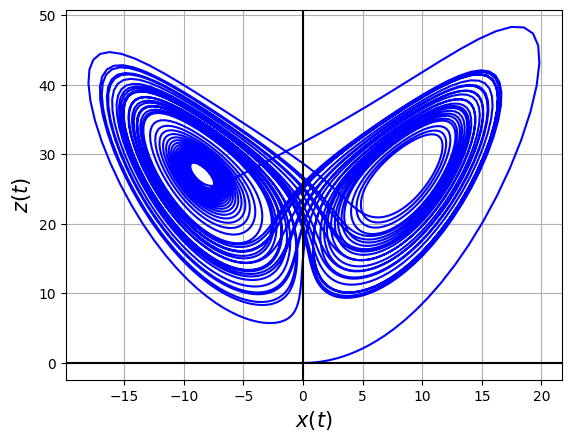

In [ ]:
pl.plot(y0,y2,c='b')
pl.xlabel(r'$x(t)$',size=15)
pl.ylabel(r'$z(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()

### **6. El péndulo simple**: Considere un péndulo con un brazo de longitud $\ell$ que sostiene una masa con valor $m$:

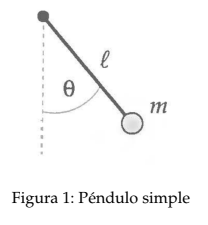

### En términos del ángulo $\theta$ de desplazamiento del brazo respecto de la vertical, la aceleración de la masa es $\ell \frac{d^2\theta}{dt^2}$ en la dirección tangencial. Mientras tanto, la fuerza sobre la masa (el peso) es en dirección vertical hacia abajo y con magnitud $mg$, donde $g = 9.81~\text{m/s}^2$ es la aceleración debida a la gravedad y (por simplicidad) ignoraremos la fricción y asumiremos que el brazo no tiene masa. La componente de esta fuerza en la dirección tangencial es $mg \sin\theta$, siempre hacia el punto de reposo en $\theta = 0$, y, por tanto, la segunda ley de Newton nos da una ecuación de movimiento para el péndulo de la forma:

$$\frac{d^2\theta}{dt^2} = -\frac{g}{\ell} \sin\theta$$

### Como vimos en clase, dado que esta ecuación es no lineal, aún no es posible resolver esta ecuación analíticamente y no se conoce una solución exacta. Sin embargo, podemos resolverla con la computadora de manera sencilla.

### Usando el truco visto en clase (para convertir una ecuación de segundo orden en dos ecuaciones de primer orden), definimos una nueva variable $\omega$ como:

$$\frac{d\theta}{dt} = \omega$$

### Entonces la ecuación de nuestro sistema se convierte en:

$$\frac{d\omega}{dt} = -\frac{g}{\ell} \sin\theta$$

### De esta forma, tenemos un sistema de dos ecuaciones de primer orden, que es equivalente a la ecuación de segundo orden con la que comenzamos. Al combinar las dos variables $\theta$ y $\omega$ en un solo vector $\vec{r} = (\theta, \omega)$ es posible resolver las dos ecuaciones simultáneamente, usando uno de los métodos que hemos visto, para dos dimensiones:

$$
\frac{d\vec{r}}{dt} = f(\vec{r}, t), \quad
\begin{pmatrix} \dot{\theta} \\ \dot{\omega} \end{pmatrix}
= f((\theta, \omega), t)
$$

#### **(a)** Escribe un programa para resolver el sistema, usando el método de Runge-Kutta de cuarto orden para un péndulo con un brazo de $\ell = 10$ cm.


In [ ]:
# Escribimos esta ecuación del péndulo simple
def dpendulo(r): # r = (theta,omega)
  g = 9.81 # m/s^2
  l = 0.1 # m

  z = np.zeros(2)
  z[0] = r[1]
  z[1] = -g/l * np.sin(r[0])
  return z

In [ ]:
x,y0,y1 = RungeKutta2D(dpendulo,([0,1]),0,10,0.01)

#### **(b)** Usa tu programa para mostrar en una sola figura:

#### 1) la gráfica del espacio fase del sistema ($\theta$ vs $\omega$) para varias condiciones iniciales del ángulo ($\theta_0$), y  
#### 2) el *campo de pendientes*.

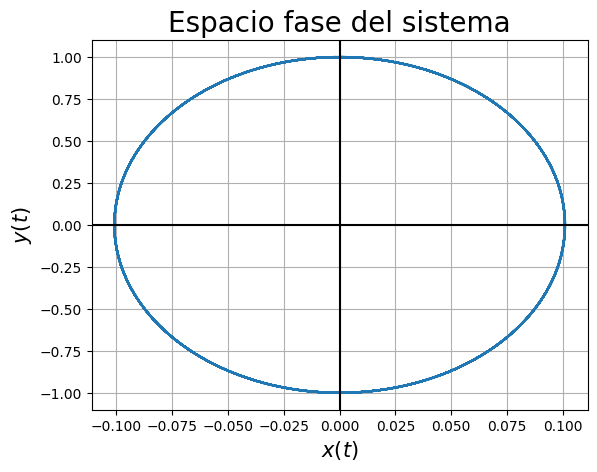

In [ ]:
pl.plot(y0,y1)
pl.title(r'Espacio fase del sistema',size=20)
pl.xlabel(r'$x(t)$',size=15)
pl.ylabel(r'$y(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()

#### **(c)** Usa el programa para graficar $\theta$ en función del tiempo, para varias condiciones iniciales (en el mismo gráfico).

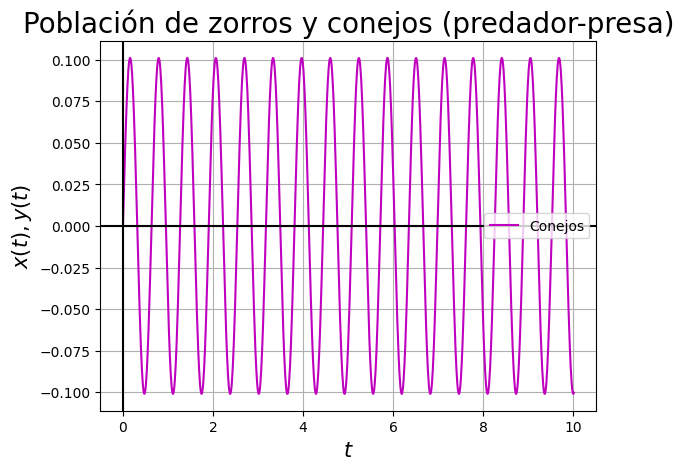

In [ ]:
pl.plot(x,y0,c='m',label='Conejos')
# pl.plot(x,y2,c='b',label='Zorros')
pl.title(r'Población de zorros y conejos (predador-presa)',size=20)
pl.xlabel(r'$t$',size=15)
pl.ylabel(r'$x(t),y(t)$',size=15)
pl.axhline(y=0.0,c='k')
pl.axvline(x=0.0,c='k')
pl.grid()
pl.legend()

#### **(d)** Describe con tus propias palabras lo que está sucediendo en el sistema.

### **7. El péndulo doble**: Ahora consideremos el *péndulo doble*, que consta de un péndulo normal del que cuelga otro péndulo en su extremo. Y al igual que en el ejercicio anterior, para simplificar, ignoramos la fricción y suponemos que ambos péndulos tienen pesas de la misma masa $m$ y brazos sin masa de la misma longitud $\ell$.

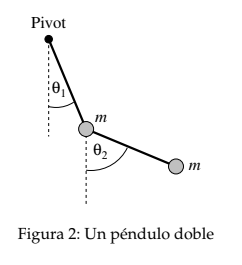

### La configuración del sistema se ve como en la figura 2. En el que la posición de los brazos en cualquier momento está especificada únicamente por los dos ángulos $\theta_1$ y $\theta_2$.

### A diferencia del péndulo simple, que aunque es no lineal, su movimiento es perfectamente regular y periódico; el péndulo doble, es completamente lo contrario: caótico e impredecible. Las ecuaciones de movimiento para los ángulos se derivan más fácilmente utilizando el formalismo Lagrangiano y que puedes revisar en el Apéndice A. De donde obtienen las siguientes cuatro ecuaciones de primer orden que definen el movimiento del péndulo doble:

$$
\dot{\theta}_1 = \omega_1, \quad \dot{\theta}_2 = \omega_2,
$$

$$
\dot{\omega}_1 = -\frac{
\omega_1^2 \sin(2\theta_1 - 2\theta_2) + 2\omega_2^2 \sin(\theta_1 - \theta_2) + \frac{g}{\ell} [\sin(\theta_1 - 2\theta_2) + 3 \sin \theta_1]
}{3 - \cos(2\theta_1 - 2\theta_2)},
$$

$$
\dot{\omega}_2 = \frac{
4\omega_1^2 \sin(\theta_1 - \theta_2) + \omega_2^2 \sin(2\theta_1 - 2\theta_2) + 2\frac{g}{\ell} [\sin(2\theta_1 - \theta_2) - \sin \theta_2]
}{3 - \cos(2\theta_1 - 2\theta_2)}
$$

#### **(a)** Deriva una expresión para la energía total $E = T + V$ del sistema en términos de las variables $\theta_1$, $\theta_2$, $\omega_1$ y $\omega_2$, más las constantes $g$, $\ell$ y $m$.

#### **(b)** Escribe un programa usando el método de Runge-Kutta de cuarto orden, para resolver las ecuaciones de movimiento para el caso donde $\ell = 40$ cm, con las condiciones iniciales $\theta_1 = \theta_2 = 90^\circ$ y $\omega_1 = \omega_2 = 0$. Usa tu programa para calcular la energía total del sistema suponiendo que la masa de las pesas es $1$ kg cada una, y haz una gráfica de la energía en función del tiempo desde $t = 0$ hasta $t = 100$ segundos.

#### Debido a la conservación de la energía, la energía total debería ser constante en el tiempo (en realidad debería ser cero para este conjunto particular de condiciones iniciales), pero encontrarás que no es perfectamente constante debido a la naturaleza aproximada de la solución de la ecuación diferencial. Elije un valor adecuado del tamaño del paso $h$ para garantizar que la variación de energía sea inferior a $10^{-5}$ Jules en el transcurso del cálculo.

In [ ]:
def RungeKutta3D_v2(dx,r0,t0,t1,h):
  T = [t0]
  X = [r0[0]]
  Y = [r0[1]]
  Z = [r0[2]]
  while t0 < t1:
    k1 = dx(r0)*h
    k2 = dx(r0+0.5*k1,t0+0.5*h)*h # Esta versión considera incrementos en t
    k3 = dx(r0+0.5*k2,t0+0.5*h)*h
    k4 = dx(r0+k3,t0+h)*h

    r = r0 + (k1 + 2*k2 + 2*k3 + k4)/6
    t = t0 + h
    T.append(t)
    X.append(r[0])
    Y.append(r[1])
    Z.append(r[2])
    r0 = r
    t0 = t
  return T,X,Y,Z